# Fase 3 — Preprocesamiento y reducción de dimensionalidad: Air Quality (UCI)

Integrante: Federico Rodríguez Franco

## Carga y limpieza

In [1]:
# En Google Colab, descomenta para subir el archivo:
# from google.colab import files
# files.upload()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

CANDIDATOS = [
    "../data/AirQualityUCI.csv",
    "data/AirQualityUCI.csv",
    "AirQualityUCI.csv",
]
RUTA = next((p for p in CANDIDATOS if os.path.exists(p)), "AirQualityUCI.csv")
print("Archivo de datos:", RUTA)

df = pd.read_csv(RUTA, sep=";", decimal=",")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df = df.replace(-200, np.nan)
df["Time"] = df["Time"].str.replace(".", ":", regex=False)
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
df = df.set_index("datetime").drop(columns=["Date", "Time"])

print("Forma:", df.shape)

Archivo de datos: ../data/AirQualityUCI.csv
Forma: (9471, 13)


## Variables para el modelado
Se descartan `NMHC` (90% faltante) y los sensores redundantes; quedan 8 variables.

In [2]:
FEATURES = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "PT08.S5(O3)", "T", "RH", "AH"]
X = df[FEATURES].copy()
print("Faltantes en X (%):")
print((X.isna().mean() * 100).round(2))

Faltantes en X (%):
CO(GT)         18.97
C6H6(GT)        5.07
NOx(GT)        18.51
NO2(GT)        18.54
PT08.S5(O3)     5.07
T               5.07
RH              5.07
AH              5.07
dtype: float64


## Codificación de categóricas
One-hot para periodo/día/mes y codificación cíclica para la hora.

In [3]:
df["hora"] = df.index.hour
df["dia_semana"] = df.index.dayofweek
df["mes"] = df.index.month
df["periodo"] = pd.cut(df["hora"], bins=[0, 6, 12, 18, 24],
                       labels=["madrugada", "manana", "tarde", "noche"], right=False)

dummies = pd.get_dummies(df[["periodo", "dia_semana", "mes"]],
                         columns=["periodo", "dia_semana", "mes"],
                         prefix=["periodo", "dia", "mes"])
print("Columnas one-hot:", list(dummies.columns))
dummies.head()

Columnas one-hot: ['periodo_madrugada', 'periodo_manana', 'periodo_tarde', 'periodo_noche', 'dia_0.0', 'dia_1.0', 'dia_2.0', 'dia_3.0', 'dia_4.0', 'dia_5.0', 'dia_6.0', 'mes_1.0', 'mes_2.0', 'mes_3.0', 'mes_4.0', 'mes_5.0', 'mes_6.0', 'mes_7.0', 'mes_8.0', 'mes_9.0', 'mes_10.0', 'mes_11.0', 'mes_12.0']


,periodo_madrugada,periodo_manana,periodo_tarde,periodo_noche,dia_0.0,dia_1.0,dia_2.0,dia_3.0,dia_4.0,dia_5.0,...,mes_3.0,mes_4.0,mes_5.0,mes_6.0,mes_7.0,mes_8.0,mes_9.0,mes_10.0,mes_11.0,mes_12.0
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2004-03-10 19:00:00,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2004-03-10 20:00:00,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2004-03-10 21:00:00,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2004-03-10 22:00:00,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False


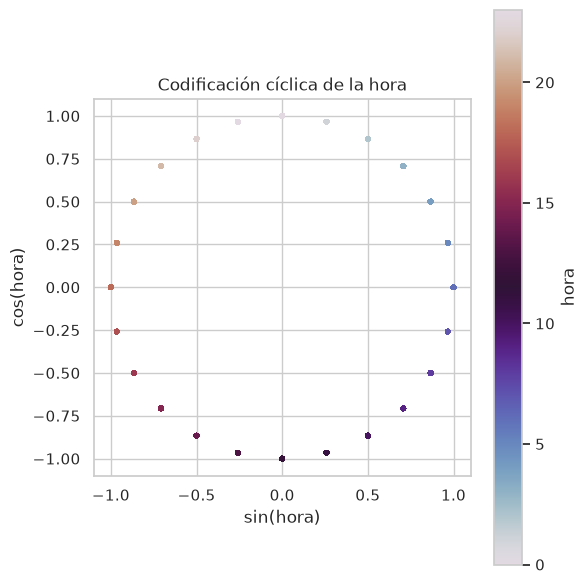

In [4]:
df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)

plt.figure(figsize=(6, 6))
plt.scatter(df["hora_sin"], df["hora_cos"], c=df["hora"], cmap="twilight", s=8)
plt.gca().set_aspect("equal")
plt.colorbar(label="hora")
plt.title("Codificación cíclica de la hora")
plt.xlabel("sin(hora)")
plt.ylabel("cos(hora)")
plt.tight_layout()
plt.show()

## Imputación (mediana)

In [5]:
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES, index=X.index)
print("Faltantes después de imputar:", X_imp.isna().sum().sum())

Faltantes después de imputar: 0


## Transformación logarítmica de las sesgadas

In [6]:
SESGADAS = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
antes = X_imp[SESGADAS].skew()
for c in SESGADAS:
    X_imp[c] = np.log1p(X_imp[c])
pd.DataFrame({"skew antes": antes, "skew después": X_imp[SESGADAS].skew()}).round(2)

,skew antes,skew después
CO(GT),1.65,0.28
C6H6(GT),1.43,-0.25
NOx(GT),2.03,-0.32
NO2(GT),0.74,-1.03


## Escalado (StandardScaler)

In [7]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_imp)
X_sc = pd.DataFrame(X_sc, columns=FEATURES, index=X_imp.index)
print("Media ≈", np.round(X_sc.mean().mean(), 6), "| Desv ≈", np.round(X_sc.std().mean(), 6))

Media ≈ 0.0 | Desv ≈ 1.000053


## PCA

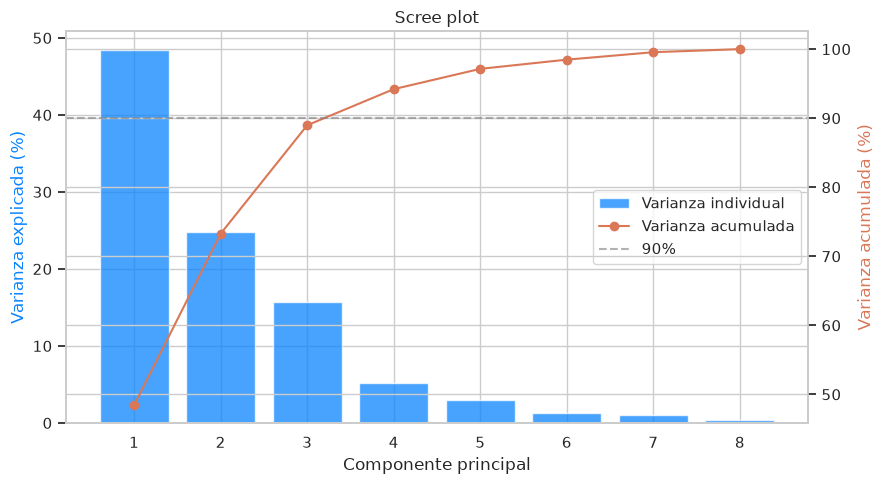

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Varianza (%),48.43,24.84,15.70,5.23,2.94,1.33,1.08,0.44
Acumulada (%),48.43,73.27,88.98,94.20,97.15,98.48,99.56,100.00


In [8]:
pca = PCA()
scores = pca.fit_transform(X_sc)

var_exp = pca.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)

fig, ax1 = plt.subplots(figsize=(9, 5))
comps = np.arange(1, len(var_exp) + 1)
ax1.bar(comps, var_exp, color="#0a84ff", alpha=.75, label="Varianza individual")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada (%)", color="#0a84ff")
ax2 = ax1.twinx()
ax2.plot(comps, var_acum, marker="o", color="#d97757", label="Varianza acumulada")
ax2.set_ylabel("Varianza acumulada (%)", color="#d97757")
ax2.axhline(90, ls="--", color="gray", alpha=.6, label="90%")
ax1.set_title("Scree plot")
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="center right")
plt.tight_layout()
plt.show()

pd.DataFrame({"Varianza (%)": var_exp.round(2), "Acumulada (%)": var_acum.round(2)},
             index=[f"PC{i}" for i in comps]).T

Con 3 componentes se conserva el **89%** de la varianza (8 → 3).

## Loadings

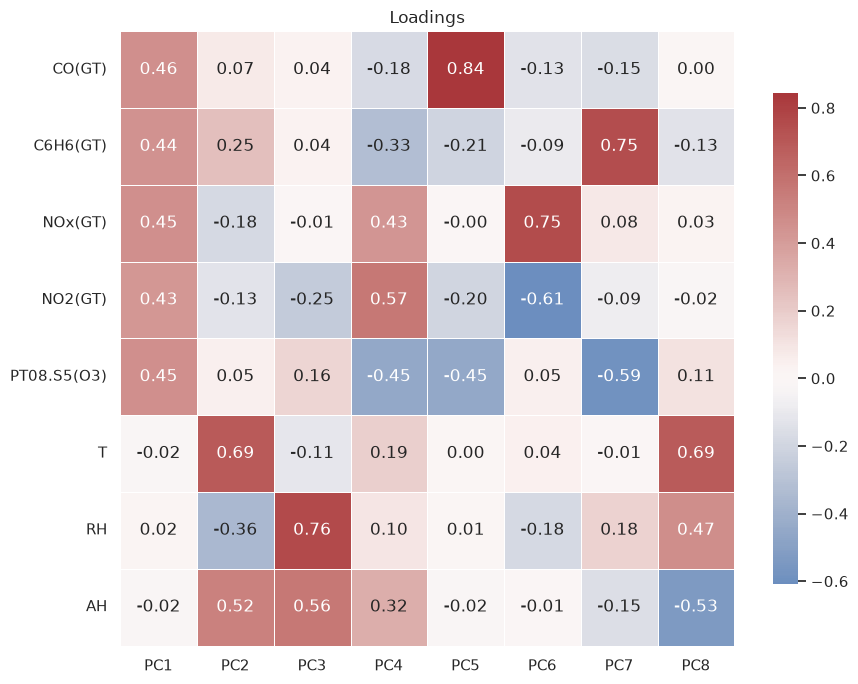

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
CO(GT),0.46,0.07,0.04,-0.18,0.84,-0.13,-0.15,0.00
C6H6(GT),0.44,0.25,0.04,-0.33,-0.21,-0.09,0.75,-0.13
NOx(GT),0.45,-0.18,-0.01,0.43,-0.00,0.75,0.08,0.03
NO2(GT),0.43,-0.13,-0.25,0.57,-0.20,-0.61,-0.09,-0.02
PT08.S5(O3),0.45,0.05,0.16,-0.45,-0.45,0.05,-0.59,0.11
T,-0.02,0.69,-0.11,0.19,0.00,0.04,-0.01,0.69
RH,0.02,-0.36,0.76,0.10,0.01,-0.18,0.18,0.47
AH,-0.02,0.52,0.56,0.32,-0.02,-0.01,-0.15,-0.53


In [9]:
loadings = pd.DataFrame(pca.components_.T, index=FEATURES,
                          columns=[f"PC{i}" for i in comps])

plt.figure(figsize=(9, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Loadings")
plt.tight_layout()
plt.show()

loadings.round(2)

**Lectura:** PC1 = contaminación (CO, C6H6, NOx, NO2, O3), PC2 = temperatura (T, AH),
PC3 = humedad (RH, AH).

## Biplot

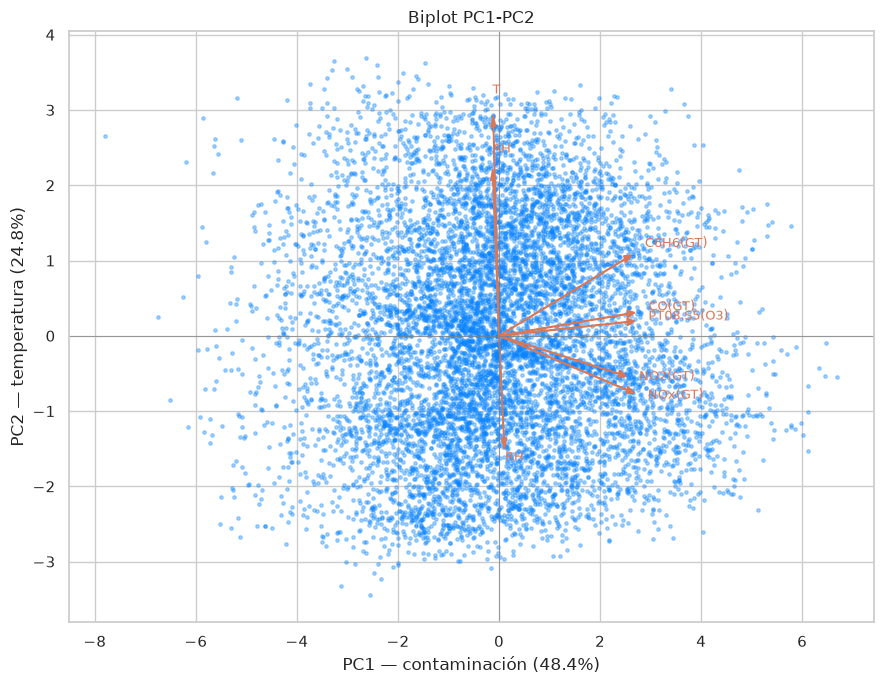

In [10]:
load = pca.components_.T[:, :2] * np.sqrt(pca.explained_variance_[:2])

plt.figure(figsize=(9, 7))
plt.scatter(scores[:, 0], scores[:, 1], s=6, alpha=.35, c="#0a84ff")
for i, c in enumerate(FEATURES):
    plt.arrow(0, 0, load[i, 0] * 3, load[i, 1] * 3,
              color="#d97757", width=.01, head_width=.10, length_includes_head=True)
    plt.text(load[i, 0] * 3.3, load[i, 1] * 3.3, c, color="#d97757", fontsize=9)
plt.axhline(0, color="gray", lw=.5)
plt.axvline(0, color="gray", lw=.5)
plt.xlabel(f"PC1 — contaminación ({var_exp[0]:.1f}%)")
plt.ylabel(f"PC2 — temperatura ({var_exp[1]:.1f}%)")
plt.title("Biplot PC1-PC2")
plt.tight_layout()
plt.show()

## t-SNE (complemento)

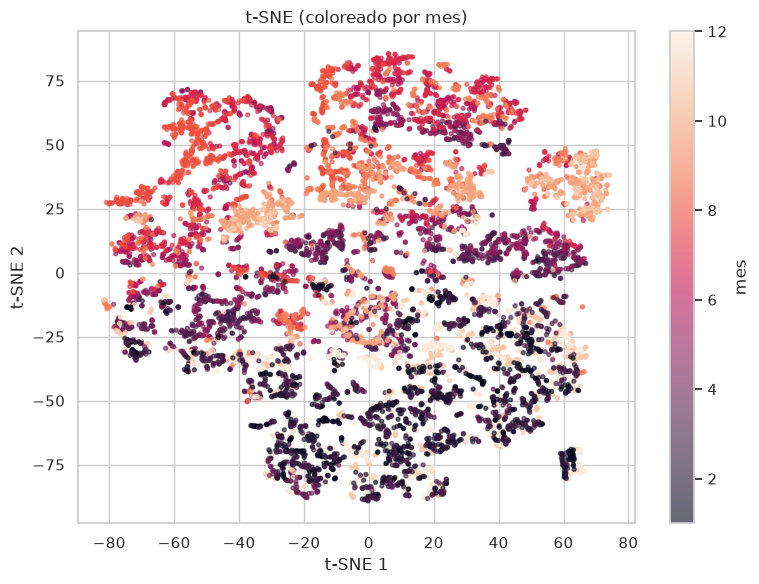

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sc)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=X_imp.index.month, cmap="rocket", s=8, alpha=.6)
plt.colorbar(sc, label="mes")
plt.title("t-SNE (coloreado por mes)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()